# Baseline models
* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 438, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 438 (delta 79), reused 135 (delta 47), pack-reused 222 (from 1)
Receiving objects: 100% (438/438), 16.84 MiB | 8.34 MiB/s, done.
Resolving deltas: 100% (184/184), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessing_pipelines import baseline_preprocessing
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import *
from src.dataset.data_augmentation import *
from src.models.vgg16CNN import create_vgg16_model
from src.models.resnet50CNN import create_resnet50_model
from src.models.mobilenetv2CNN import create_mobilenetv2_model
from src.models.densenet121CNN import create_densenet121_model
from src.models.efficientnetb0CNN import create_efficientnetb0_model
from src.visualizations import *

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels = val_df['pathology'].to_numpy()

In [ ]:
# CSV Files to store all baseline results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/baseline_results.csv"

In [ ]:
# Constants
BATCH_SIZE = 32
BUFFER_SIZE = len(train_df)
TOTAL_TRAINING_SAMPLES = len(train_df)
CLASSES = 2
PREDICTION_THRESHOLD = 0.5
EPOCHS = 20

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_df, CLASSES, TOTAL_TRAINING_SAMPLES)

### tf.data Dataset Preparation for Baseline

In [ ]:
# Baseline (resizing + model-specific normalization) preprocessing
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

In [ ]:
# Generate training dataset for the baselines
train_dataset = generate_dataset(train_df, baseline_preprocessor)
# Shuffle training dataset samples
train_dataset = shuffle_training_dataset(train_dataset, BUFFER_SIZE)
# Add data augmentation to training dataset
train_dataset = data_augmented_dataset(train_dataset)
# Batch and prefetch the dataset
train_dataset = batch_dataset(train_dataset, BATCH_SIZE)

# Generate validation dataset for the baselines
val_dataset = generate_dataset(val_df, baseline_preprocessor)
# Batch and prefetch the validation dataset
val_dataset = batch_dataset(val_dataset, BATCH_SIZE)

## VGG16

In [ ]:
# Create a VGG16 model instance and compile it
vgg16_model = create_vgg16_model()
vgg16_model = compile_model(vgg16_model)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print vgg16 model summary
vgg16_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train VGG16 with training dataset with baseline preprocessor
vgg16_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 46s 470ms/step - accuracy: 0.5244 - auc: 0.5155 - loss: 1.0030 - precision: 0.4061 - recall: 0.4259 - val_accuracy: 0.5945 - val_auc: 0.5995 - val_loss: 0.6865 - val_precision: 0.4792 - val_recall: 0.4000
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 469ms/step - accuracy: 0.5930 - auc: 0.5873 - loss: 0.8158 - precision: 0.4869 - recall: 0.4524 - val_accuracy: 0.6525 - val_auc: 0.6118 - val_loss: 0.6299 - val_precision: 0.6250 - val_recall: 0.2826
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 474ms/step - accuracy: 0.6053 - auc: 0.6021 - loss: 0.7798 - precision: 0.5036 - recall: 0.4668 - val_accuracy: 0.6610 - val_auc: 0.6214 - val_loss: 0.6116 - val_precision: 0.6782 - val_recall: 0.2565
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 470ms/step - accuracy: 0.6185 - auc: 0.6153 - loss: 0.7611 - precision: 0.5215 - recall: 0.4834 - val_accuracy: 0.6559 - val_auc: 0.6180 - val_loss: 0.6042 - val_precision: 0.6707 - val_recall: 0.2391
Epoch 5/20
72/72 ━━━━━━━━━━━

In [ ]:
# Get validation logits
val_logits_vgg = vgg16_model.predict(val_dataset)

# Get validation probabilities
val_probabilities_vgg = tf.nn.sigmoid(val_logits_vgg)

# Get validation dataset predictions
val_predictions_vgg = tf.cast(val_probabilities_vgg >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step


In [ ]:
# Evaluation metrics
eval_metrics_vgg = vgg16_model.evaluate(val_dataset, return_dict=True)
# F1 Score
f1_score_vgg = compute_f1_score(eval_metrics_vgg['precision'], eval_metrics_vgg['recall'])
# Confusion Matrix
tn_vgg, fp_vgg, fn_vgg, tp_vgg = confusion_matrix(val_true_labels, val_predictions_vgg).ravel()
# Specificity
specificity_vgg = compute_specificity(tn_vgg, fp_vgg)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step - accuracy: 0.6593 - auc: 0.6517 - loss: 0.5788 - precision: 0.6667 - recall: 0.2609


In [ ]:
# Store evaluation metrics in a csv file
results_df_vgg = generate_image_preprocessing_results_df(
    'VGG16',
    'Baseline',
    eval_metrics_vgg,
    specificity_vgg,
    f1_score_vgg)

store_experiment_results(results_file_path, results_df_vgg)

Stored results for 0    Baseline
Name: image_preprocessing_pipeline, dtype: object pipeline


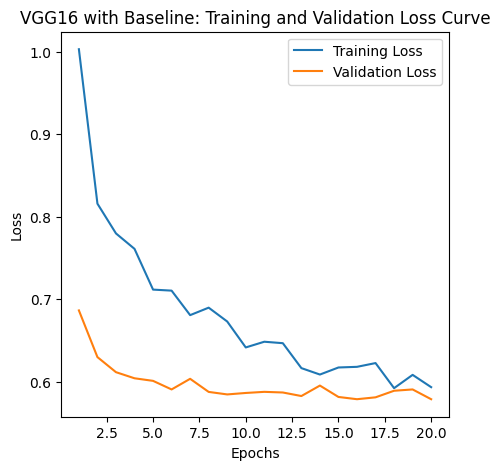

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_model.history, 'VGG16', 'Baseline')

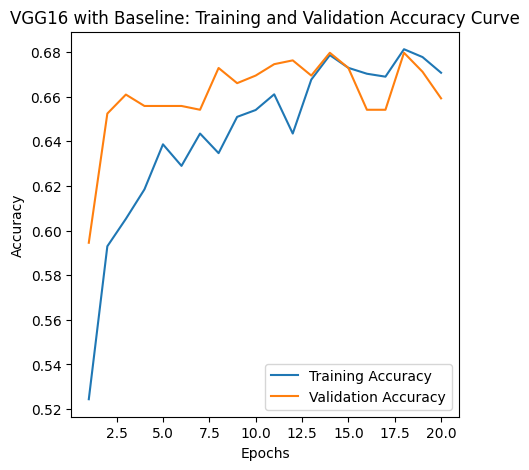

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16_model.history, 'VGG16', 'Baseline')

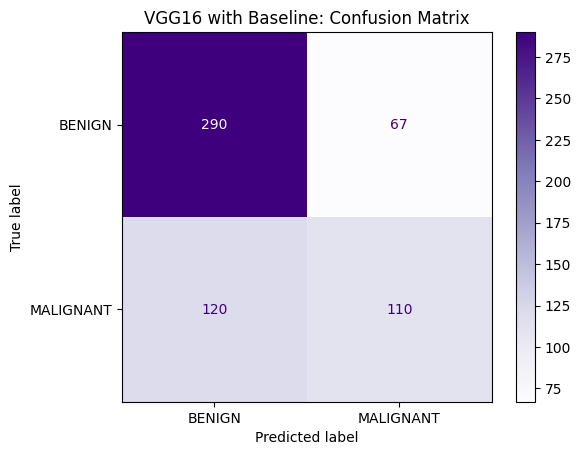

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_vgg, 'VGG16', 'Baseline')

## ResNet50

In [ ]:
# Create a ResNet50 model instance and compile it
resnet50_model = create_resnet50_model()
resnet50_model = compile_model(resnet50_model)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print resnet50 model summary
resnet50_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train ResNet50 with training dataset for the baseline
resnet50_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 494ms/step - accuracy: 0.6092 - auc: 0.5998 - loss: 0.7003 - precision: 0.5103 - recall: 0.4093 - val_accuracy: 0.6865 - val_auc: 0.6578 - val_loss: 0.5928 - val_precision: 0.7130 - val_recall: 0.3348
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 459ms/step - accuracy: 0.6453 - auc: 0.6494 - loss: 0.6409 - precision: 0.5698 - recall: 0.4381 - val_accuracy: 0.6814 - val_auc: 0.7005 - val_loss: 0.5989 - val_precision: 0.6243 - val_recall: 0.4696
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 465ms/step - accuracy: 0.6699 - auc: 0.6810 - loss: 0.6080 - precision: 0.6035 - recall: 0.4934 - val_accuracy: 0.6917 - val_auc: 0.6755 - val_loss: 0.5637 - val_precision: 0.8025 - val_recall: 0.2826
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.6752 - auc: 0.6786 - loss: 0.6095 - precision: 0.6256 - recall: 0.4546 - val_accuracy: 0.6917 - val_auc: 0.7047 - val_loss: 0.5742 - val_precision: 0.6788 - val_recall: 0.4043
Epoch 5/20
72/72 ━━━━━━━━━━━

In [ ]:
# Get validation logits
val_logits_resnet = resnet50_model.predict(val_dataset)

# Get validation probabilities
val_probabilities_resnet = tf.nn.sigmoid(val_logits_resnet)

# Get validation dataset predictions
val_predictions_resnet = tf.cast(val_probabilities_resnet >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 280ms/step


In [ ]:
# Evaluation metrics
eval_metrics_resnet = resnet50_model.evaluate(val_dataset, return_dict=True)
# F1 Score
f1_score_resnet = compute_f1_score(eval_metrics_resnet['precision'], eval_metrics_resnet['recall'])
# Confusion Matrix
tn_resnet, fp_resnet, fn_resnet, tp_resnet = confusion_matrix(val_true_labels, val_predictions_resnet).ravel()
# Specificity
specificity_resnet = compute_specificity(tn_resnet, fp_resnet)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7019 - auc: 0.7054 - loss: 0.5373 - precision: 0.7670 - recall: 0.3435


In [ ]:
# Store evaluation metrics in a csv file
results_df_resnet = generate_image_preprocessing_results_df(
    'ResNet50',
    'Baseline',
    eval_metrics_resnet,
    specificity_resnet,
    f1_score_resnet)

store_experiment_results(results_file_path, results_df_resnet)

Stored results for 0    Baseline
Name: image_preprocessing_pipeline, dtype: object pipeline


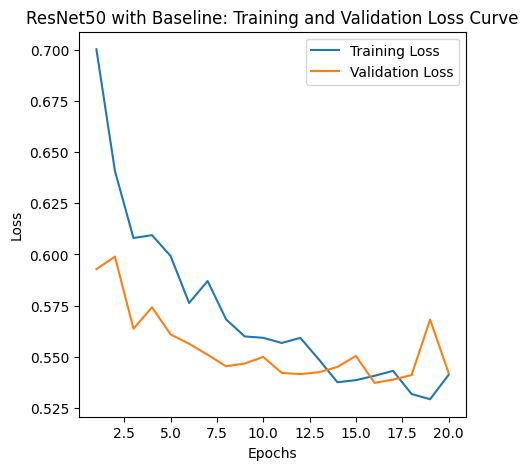

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_model.history, 'ResNet50', 'Baseline')

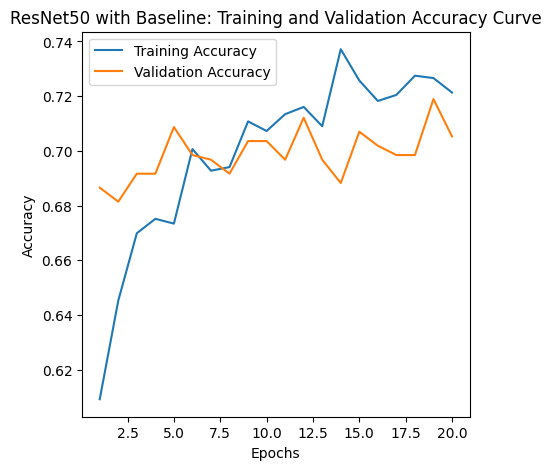

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50_model.history, 'ResNet50', 'Baseline')

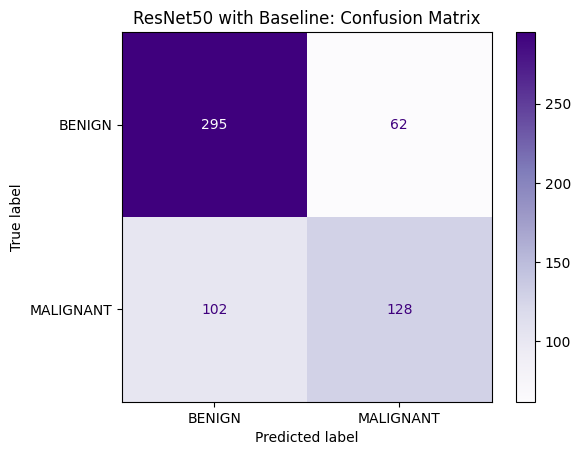

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_resnet, 'ResNet50', 'Baseline')

## DenseNet121

In [ ]:
# Create a DenseNet121 model instance and compile it
densenet121_model = create_densenet121_model()
densenet121_model = compile_model(densenet121_model)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print DenseNet121 model summary
densenet121_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
# Train DenseNet121 with training dataset for the baseline
densenet121_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 544ms/step - accuracy: 0.5495 - auc: 0.5392 - loss: 1.3080 - precision: 0.4366 - recall: 0.4613 - val_accuracy: 0.6235 - val_auc: 0.5603 - val_loss: 0.7220 - val_precision: 0.5634 - val_recall: 0.1739
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 483ms/step - accuracy: 0.5776 - auc: 0.5585 - loss: 1.0623 - precision: 0.4662 - recall: 0.4347 - val_accuracy: 0.6014 - val_auc: 0.5756 - val_loss: 0.6779 - val_precision: 0.4778 - val_recall: 0.1870
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.5855 - auc: 0.5633 - loss: 0.9637 - precision: 0.4748 - recall: 0.4060 - val_accuracy: 0.6269 - val_auc: 0.5864 - val_loss: 0.6646 - val_precision: 0.5545 - val_recall: 0.2435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 482ms/step - accuracy: 0.6123 - auc: 0.5985 - loss: 0.8474 - precision: 0.5147 - recall: 0.4248 - val_accuracy: 0.6508 - val_auc: 0.6307 - val_loss: 0.6225 - val_precision: 0.6404 - val_recall: 0.2478
Epoch 5/20
72/72 ━━━━━━━━━━━

In [ ]:
# Get validation logits
val_logits_densenet = densenet121_model.predict(val_dataset)

# Get validation probabilities
val_probabilities_densenet = tf.nn.sigmoid(val_logits_densenet)

# Get validation dataset predictions
val_predictions_densenet = tf.cast(val_probabilities_densenet >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 372ms/step


In [ ]:
# Evaluation metrics
eval_metrics_densenet = densenet121_model.evaluate(val_dataset, return_dict=True)
# F1 Score
f1_score_densenet = compute_f1_score(eval_metrics_densenet['precision'], eval_metrics_densenet['recall'])
# Confusion Matrix
tn_densenet, fp_densenet, fn_densenet, tp_densenet = confusion_matrix(val_true_labels, val_predictions_densenet).ravel()
# Specificity
specificity_densenet = compute_specificity(tn_densenet, fp_densenet)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.6235 - auc: 0.5603 - loss: 0.7220 - precision: 0.5634 - recall: 0.1739


In [ ]:
# Store evaluation metrics in a csv file
results_df_densenet = generate_image_preprocessing_results_df(
    'DenseNet121',
    'Baseline',
    eval_metrics_densenet,
    specificity_densenet,
    f1_score_densenet)

store_experiment_results(results_file_path, results_df_densenet)

Stored results for 0    Baseline
Name: image_preprocessing_pipeline, dtype: object pipeline


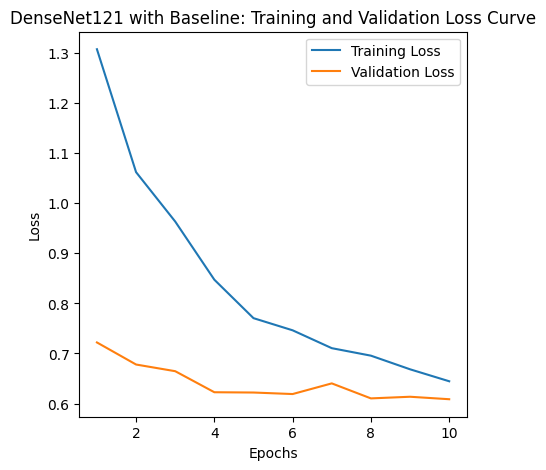

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_model.history, 'DenseNet121', 'Baseline')

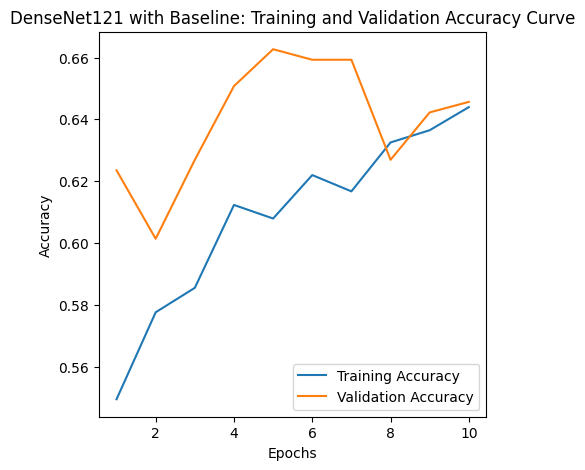

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121_model.history, 'DenseNet121', 'Baseline')

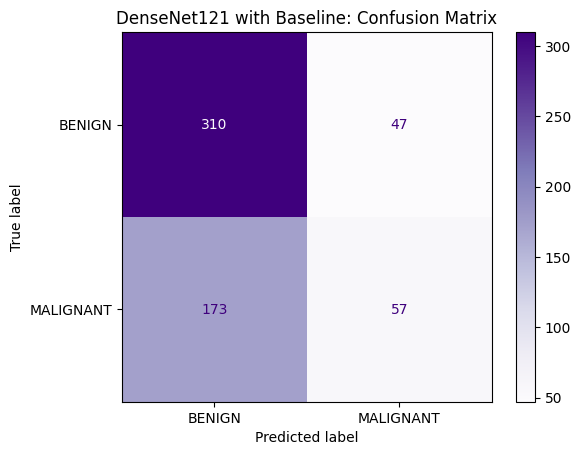

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_densenet, 'DenseNet121', 'Baseline')

## MobileNetv2

In [ ]:
# Create a MobileNetV2 model instance and compile it
mobilenetv2_model = create_mobilenetv2_model()
mobilenetv2_model = compile_model(mobilenetv2_model)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print MobileNetV2 model summary
mobilenetv2_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train MobileNetV2 with training dataset for baseline
mobilenetv2_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 433ms/step - accuracy: 0.5569 - auc: 0.5202 - loss: 0.7522 - precision: 0.4217 - recall: 0.3097 - val_accuracy: 0.6269 - val_auc: 0.5810 - val_loss: 0.6540 - val_precision: 0.7200 - val_recall: 0.0783
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 414ms/step - accuracy: 0.5996 - auc: 0.5826 - loss: 0.7074 - precision: 0.4942 - recall: 0.3319 - val_accuracy: 0.6286 - val_auc: 0.6296 - val_loss: 0.6729 - val_precision: 0.5600 - val_recall: 0.2435
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 411ms/step - accuracy: 0.6158 - auc: 0.6082 - loss: 0.6782 - precision: 0.5244 - recall: 0.3562 - val_accuracy: 0.6405 - val_auc: 0.6372 - val_loss: 0.6458 - val_precision: 0.6667 - val_recall: 0.1652
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 412ms/step - accuracy: 0.6303 - auc: 0.6161 - loss: 0.6671 - precision: 0.5533 - recall: 0.3617 - val_accuracy: 0.6269 - val_auc: 0.6076 - val_loss: 0.6351 - val_precision: 0.6410 - val_recall: 0.1087
Epoch 5/20
72/72 ━━━━━━━━━━━

In [ ]:
# Get validation logits
val_logits_mobilenet = mobilenetv2_model.predict(val_dataset)

# Get validation probabilities
val_probabilities_mobilenet = tf.nn.sigmoid(val_logits_mobilenet)

# Get validation dataset predictions
val_predictions_mobilenet = tf.cast(val_probabilities_mobilenet >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step


In [ ]:
# Evaluation metrics
eval_metrics_mobilenet = mobilenetv2_model.evaluate(val_dataset, return_dict=True)
# F1 Score
f1_score_mobilenet = compute_f1_score(eval_metrics_mobilenet['precision'], eval_metrics_mobilenet['recall'])
# Confusion Matrix
tn_mobilenet, fp_mobilenet, fn_mobilenet, tp_mobilenet = confusion_matrix(val_true_labels, val_predictions_mobilenet).ravel()
# Specificity
specificity_mobilenet = compute_specificity(tn_mobilenet, fp_mobilenet)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.6269 - auc: 0.5810 - loss: 0.6540 - precision: 0.7200 - recall: 0.0783


In [ ]:
# Store evaluation metrics in a csv file
results_df_mobilenet = generate_image_preprocessing_results_df(
    'MobileNetV2',
    'Baseline',
    eval_metrics_mobilenet,
    specificity_mobilenet,
    f1_score_mobilenet)

store_experiment_results(results_file_path, results_df_mobilenet)

Stored results for 0    Baseline
Name: image_preprocessing_pipeline, dtype: object pipeline


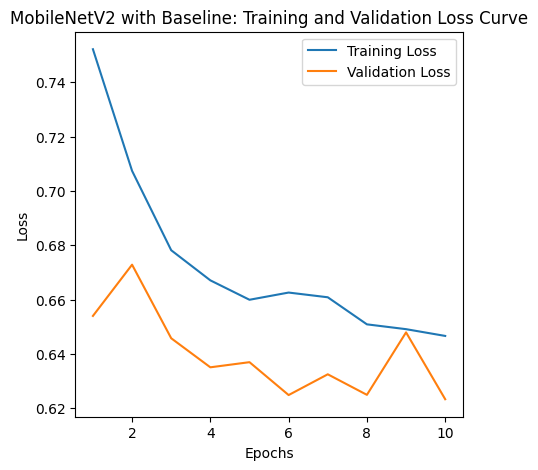

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_model.history, 'MobileNetV2', 'Baseline')

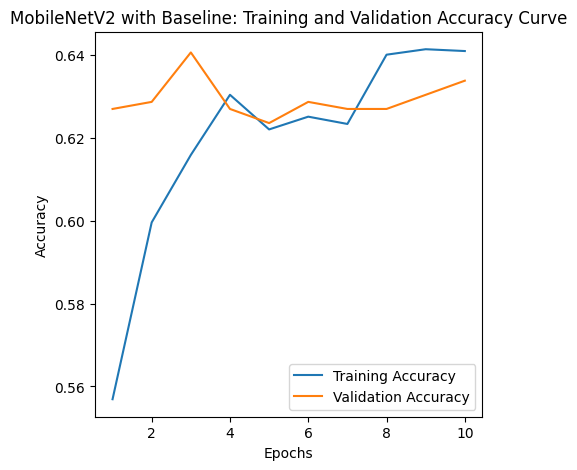

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2_model.history, 'MobileNetV2', 'Baseline')

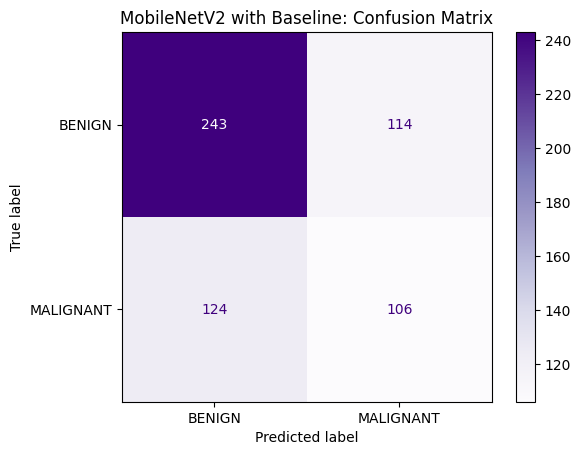

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_mobilenet, 'MobileNetV2', 'Baseline')

## EfficientNet-B0

In [ ]:
# Create a EfficientNetB0 model instance and compile it
efficientnetb0_model = create_efficientnetb0_model()
efficientnetb0_model = compile_model(efficientnetb0_model)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Print EfficientNetB0 model summary
efficientnetb0_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Train EfficientNetB0 with training dataset for Baseline
efficientnetb0_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights_dict)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 479ms/step - accuracy: 0.6295 - auc: 0.6281 - loss: 0.6544 - precision: 0.5805 - recall: 0.2434 - val_accuracy: 0.6559 - val_auc: 0.6626 - val_loss: 0.6218 - val_precision: 0.6000 - val_recall: 0.3652
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 436ms/step - accuracy: 0.6576 - auc: 0.6495 - loss: 0.6297 - precision: 0.6155 - recall: 0.3684 - val_accuracy: 0.6712 - val_auc: 0.6808 - val_loss: 0.6054 - val_precision: 0.6294 - val_recall: 0.3913
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 462ms/step - accuracy: 0.6651 - auc: 0.6726 - loss: 0.6134 - precision: 0.6420 - recall: 0.3551 - val_accuracy: 0.6644 - val_auc: 0.6971 - val_loss: 0.6120 - val_precision: 0.5882 - val_recall: 0.4783
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 428ms/step - accuracy: 0.6690 - auc: 0.6889 - loss: 0.6064 - precision: 0.6327 - recall: 0.3982 - val_accuracy: 0.6848 - val_auc: 0.6896 - val_loss: 0.5888 - val_precision: 0.6744 - val_recall: 0.3783
Epoch 5/20
72/72 ━━━━━━━━━━━

In [ ]:
# Get validation logits
val_logits_efficientnet = efficientnetb0_model.predict(val_dataset)

# Get validation probabilities
val_probabilities_efficientnet = tf.nn.sigmoid(val_logits_efficientnet)

# Get validation dataset predictions
val_predictions_efficientnet = tf.cast(val_probabilities_efficientnet >= PREDICTION_THRESHOLD, tf.float32)

19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step


In [ ]:
# Evaluation metrics
eval_metrics_efficientnet = efficientnetb0_model.evaluate(val_dataset, return_dict=True)
# F1 Score
f1_score_efficientnet = compute_f1_score(eval_metrics_efficientnet['precision'], eval_metrics_efficientnet['recall'])
# Confusion Matrix
tn_efficientnet, fp_efficientnet, fn_efficientnet, tp_efficientnet = confusion_matrix(val_true_labels, val_predictions_efficientnet).ravel()
# Specificity
specificity_efficientnet = compute_specificity(tn_efficientnet, fp_efficientnet)

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.6559 - auc: 0.6626 - loss: 0.6218 - precision: 0.6000 - recall: 0.3652


In [ ]:
# Store evaluation metrics in a csv file
results_df_efficientnet = generate_image_preprocessing_results_df(
    'EfficientNet-B0',
    'Baseline',
    eval_metrics_efficientnet,
    specificity_efficientnet,
    f1_score_efficientnet)

store_experiment_results(results_file_path, results_df_efficientnet)

Stored results for 0    Baseline
Name: image_preprocessing_pipeline, dtype: object pipeline


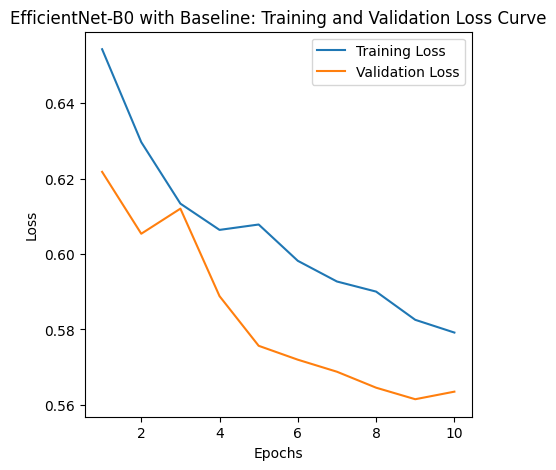

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_model.history, 'EfficientNet-B0', 'Baseline')

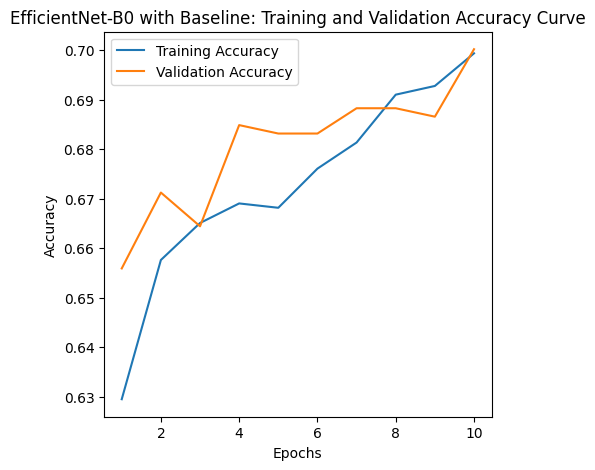

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0_model.history, 'EfficientNet-B0', 'Baseline')

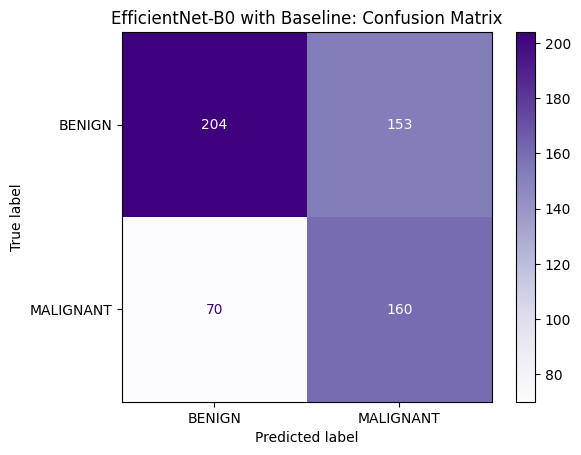

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(val_true_labels, val_predictions_efficientnet, 'EfficientNet-B0', 'Baseline')